# TF-IDF 세부사업 영역분류 모델 학습·평가

- 이슈: #65
- 학습 데이터: 2021년 17개 시도 영역분류 정답 라벨
- 예측 대상: 2016~2020년, 2022~2024년 정제 세부사업
- 비교 입력: `세부사업명` / `세부사업명 + 주요내용_정제`
- 평가: 지역 단위 5-fold 교차검증, macro-F1 우선
- 주요내용 결측 행은 세부사업명만 사용합니다.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.train_tfidf_area_classifier import run_training  # noqa: E402
from src.visualization.plots import KOREAN_FONT  # noqa: E402

np.random.seed(42)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", rc={"font.family": KOREAN_FONT})
plt.rcParams["axes.unicode_minus"] = False

In [8]:
TRAINING_PATH = (
    PROJECT_ROOT / "data/interim/영역분류_라벨링/2021/통합/2021_17개시도_TFIDF_학습데이터.csv"
)
PREDICTION_PATH = (
    PROJECT_ROOT
    / "data/interim/영역분류_라벨링/TFIDF_분류대상/2016_2020_2022_2024_TFIDF_분류대상.csv"
)
OUTPUT_DIR = PROJECT_ROOT / "data/processed/영역분류_라벨링/TFIDF_예측"
MODEL_PATH = PROJECT_ROOT / "models/tfidf_area_classifier.joblib"

training = pd.read_csv(TRAINING_PATH)
targets = pd.read_csv(PREDICTION_PATH)

display(
    {
        "학습행": len(training),
        "학습지역": training["지역"].nunique(),
        "세부영역": training["세부영역"].nunique(),
        "예측행": len(targets),
        "예측연도": sorted(targets["연도"].unique()),
    }
)

{'학습행': 7301,
 '학습지역': 17,
 '세부영역': 12,
 '예측행': 50678,
 '예측연도': [np.int64(2016),
  np.int64(2017),
  np.int64(2018),
  np.int64(2019),
  np.int64(2020),
  np.int64(2022),
  np.int64(2023),
  np.int64(2024)]}

In [9]:
label_distribution = (
    training.groupby(["대영역", "세부영역"], dropna=False)
    .size()
    .rename("행수")
    .reset_index()
    .sort_values("행수", ascending=False)
)
label_distribution

,대영역,세부영역,행수
11,지표체계 외,지표체계 외,2099
3,2. 가족·생활,2-1. 돌봄 여건,1850
2,1. 경제·고용·주거,1-3. 경제적 여건,640
6,3. 보건·안전,3-1. 의료서비스 여건,632
0,1. 경제·고용·주거,1-1. 고용여건,551
10,4. 사회·문화,4-2. 사회적 가치관,451
8,3. 보건·안전,3-3. 아동안전 수준,276
4,2. 가족·생활,2-2. 여가 인프라,268
9,4. 사회·문화,4-1. 일·가정 양립 여건,224
7,3. 보건·안전,3-2. 산후조리 여건,150


## 모델 학습 및 8개년 예측

아래 셀은 평가표·교차검증 예측·혼동행렬·8개년 예측·저신뢰 검토 목록과 재사용 모델 번들을 생성합니다. 입력 파일과 설정이 같고 기존 산출물이 모두 있으면 재학습하지 않고 바로 재사용합니다. 다시 학습하려면 `force=True`로 변경합니다.

In [10]:
summary = run_training(
    TRAINING_PATH,
    PREDICTION_PATH,
    OUTPUT_DIR,
    MODEL_PATH,
    low_confidence_threshold=0.5,
    n_splits=5,
    force=False,
)
summary

{'selected_text_variant': '사업명_주요내용',
 'selected_metrics': {'accuracy': 0.8627585262292836,
  'f1_macro': 0.8422310740983595,
  'f1_weighted': 0.864809507161807},
 'prediction_rows': 50678,
 'low_confidence_rows': 18122,
 'low_confidence_threshold': 0.5,
 'model_path': '/Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha/models/tfidf_area_classifier.joblib',
 'review_workbook_path': '/Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha/data/processed/영역분류_라벨링/TFIDF_예측/2016_2020_2022_2024_TFIDF_영역분류_검토.xlsx'}

실행 결과에 포함된 `review_workbook_path`의 Excel 파일은 전체 예측을 저신뢰 순으로 정렬합니다. `검토_세부영역`과 `검토상태`는 드롭다운이며, 세부영역을 바꾸면 `검토_대영역`이 자동으로 갱신됩니다.

In [11]:
model_comparison = pd.read_csv(OUTPUT_DIR / "TFIDF_모델_비교.csv")
model_comparison

,입력방식,accuracy,f1_macro,f1_weighted
0,사업명_주요내용,0.862759,0.842231,0.86481
1,사업명,0.821394,0.778231,0.82489


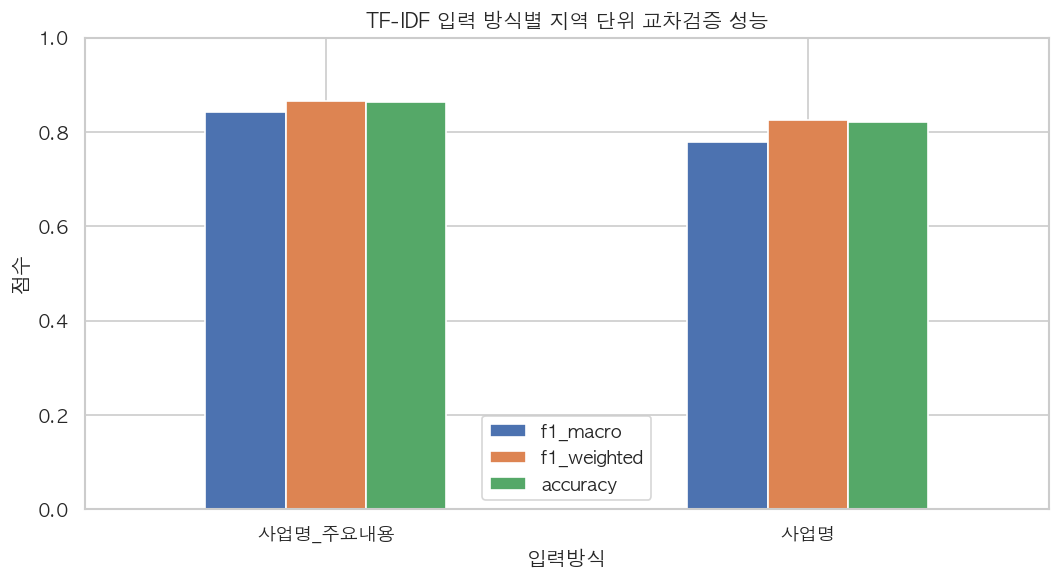

In [12]:
ax = model_comparison.set_index("입력방식")[["f1_macro", "f1_weighted", "accuracy"]].plot(
    kind="bar", figsize=(9, 5), ylim=(0, 1), rot=0
)
ax.set_title("TF-IDF 입력 방식별 지역 단위 교차검증 성능")
ax.set_ylabel("점수")
plt.tight_layout()
plt.show()

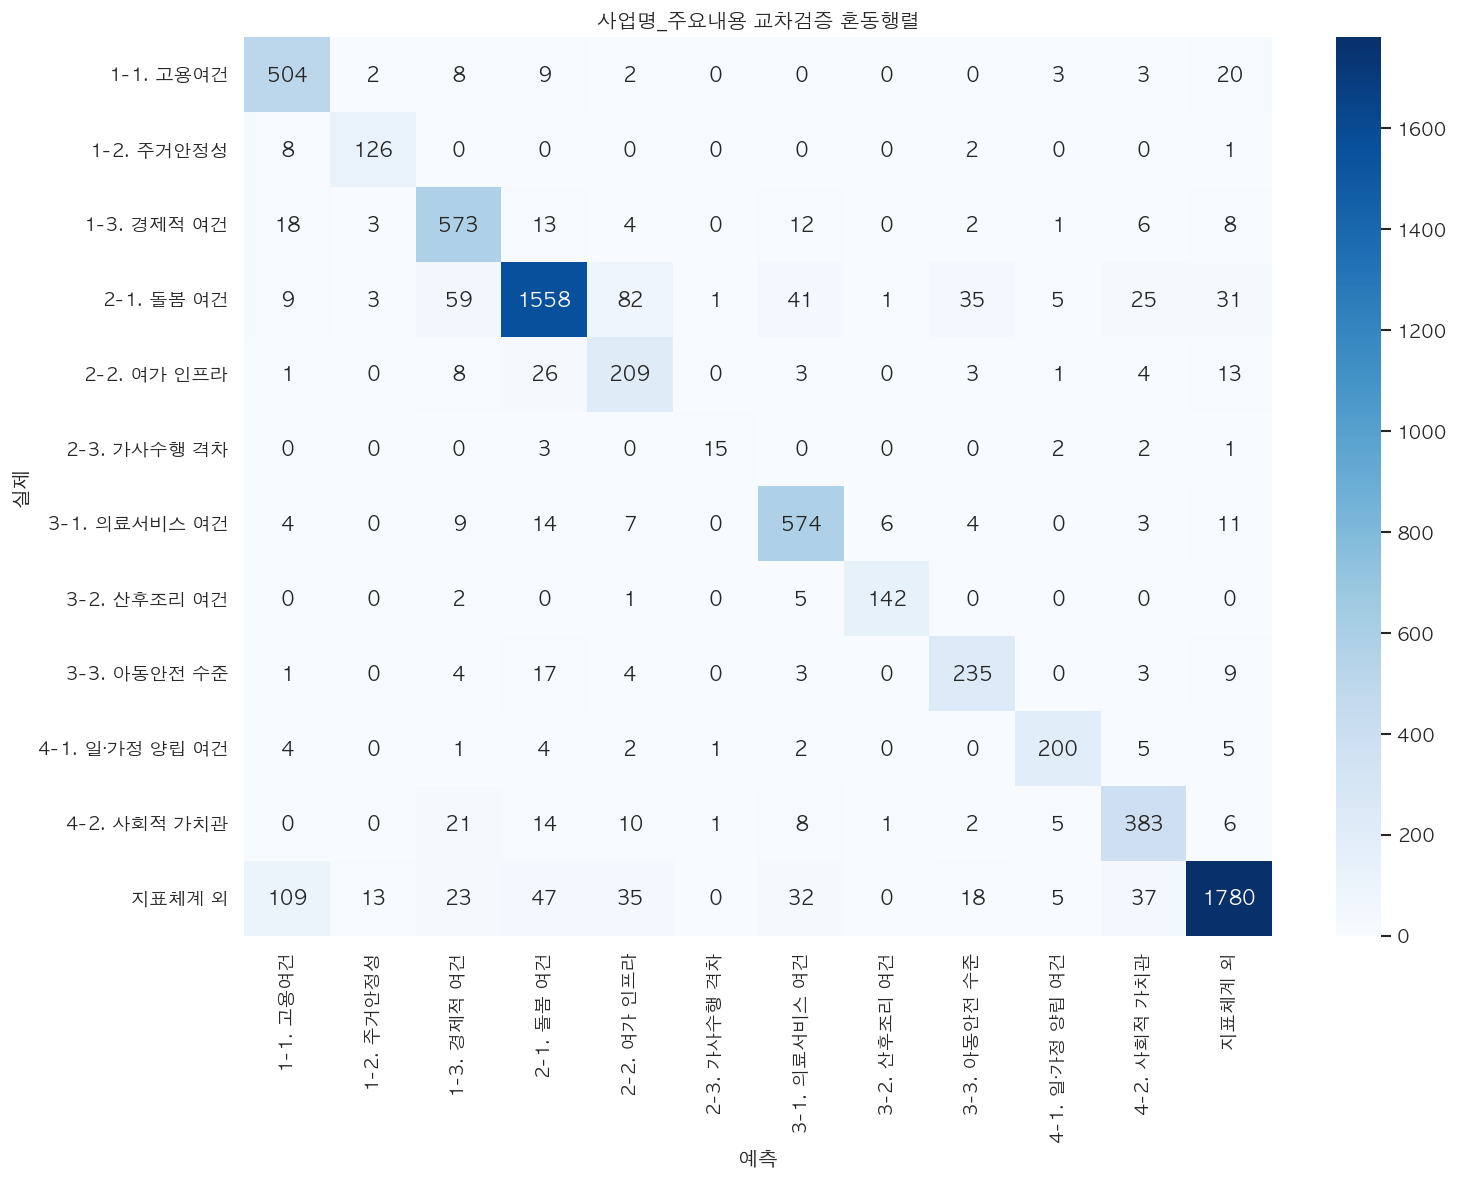

In [13]:
selected_variant = summary["selected_text_variant"]
confusion = pd.read_csv(
    OUTPUT_DIR / f"TFIDF_{selected_variant}_혼동행렬.csv",
    index_col=0,
)
plt.figure(figsize=(13, 10))
sns.heatmap(confusion, cmap="Blues", annot=True, fmt="g")
plt.title(f"{selected_variant} 교차검증 혼동행렬")
plt.xlabel("예측")
plt.ylabel("실제")
plt.tight_layout()
plt.show()

## 저신뢰 임계값 검토

0.5는 보수적인 기본값입니다. 아래 표에서 임계값별 검토량과 교차검증 오류 포착률을 확인한 뒤 실제 수작업 검토 범위에 맞게 조정합니다.

In [14]:
cv_predictions = pd.read_csv(OUTPUT_DIR / f"TFIDF_{selected_variant}_교차검증_예측.csv")
predictions = pd.read_csv(OUTPUT_DIR / "2016_2020_2022_2024_TFIDF_영역분류_예측.csv")
error_count = (~cv_predictions["정답일치"]).sum()
threshold_rows = []
for threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    cv_review = cv_predictions["예측_신뢰도"].lt(threshold)
    target_review = predictions["예측_신뢰도"].lt(threshold)
    threshold_rows.append(
        {
            "임계값": threshold,
            "교차검증_검토비율": cv_review.mean(),
            "교차검증_오류포착률": ((~cv_predictions["정답일치"]) & cv_review).sum() / error_count,
            "예측대상_검토건수": target_review.sum(),
            "예측대상_검토비율": target_review.mean(),
        }
    )
pd.DataFrame(threshold_rows)

,임계값,교차검증_검토비율,교차검증_오류포착률,예측대상_검토건수,예측대상_검토비율
0,0.25,0.081222,0.265469,2946,0.058132
1,0.30,0.152034,0.446108,5804,0.114527
2,0.35,0.223805,0.587824,8849,0.174612
3,0.40,0.288043,0.699601,11931,0.235428
4,0.45,0.355294,0.772455,14976,0.295513
5,0.50,0.418299,0.836327,18122,0.357591


In [15]:
qa = pd.read_csv(OUTPUT_DIR / "2016_2020_2022_2024_TFIDF_예측_QA.csv")
qa.groupby("연도")[["행수", "저신뢰_건수"]].sum().assign(
    저신뢰_비율=lambda frame: frame["저신뢰_건수"] / frame["행수"]
)

,행수,저신뢰_건수,저신뢰_비율
연도,,,
2016,4494,1756,0.390743
2017,4551,1630,0.358163
2018,5472,1977,0.361294
2019,6484,2179,0.336058
2020,6858,2281,0.332604
2022,8122,2810,0.345974
2023,7543,2772,0.367493
2024,7154,2717,0.379788
